# He and H population

2020.06.10   k.i.

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

In [2]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity
from spectra.Util import HelpUtil
from spectra.Visual import Plotting#, Grotrian
from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
from spectra.Atomic import Hydrogen

## Create atomic model

In [3]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )
atom_H, wMesh_H, path_dict_H = Atom.init_Atom_(conf_path , is_hydrogen=True)


In [4]:
HelpUtil.help_( atom_H )
path_dict_H

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 1
|- Mass                    float                                v: 1.008
|- Abun                    float                                v: 1.0
|- nLevel                  int                                  v: 9
|- nLine                   int                                  v: 28
|- nCont                   int                                  v: 8
|- nTran                   int                                  v: 36
|- nRL                     int                                  v: 0
|- Level                   struct array                         s: (9,)
  |-  erg                  float64                              s: (9,)
  |-  g                    in

{'folder': 'D:\\home\\Python\\spectra\\data\\atom\\H',
 'conf': 'D:\\home\\Python\\spectra\\data\\conf\\H.conf',
 'Level': 'D:\\home\\Python\\spectra\\data\\atom\\H\\H.Level',
 'Aji': 'D:\\home\\Python\\spectra\\data\\atom\\H\\Einstein_A\\Nist.Aji',
 'CEe': None,
 'CIe': None,
 'PI': None,
 'RadiativeLine': None,
 'Grotrian': 'D:\\home\\Python\\spectra\\data\\atom\\H\\H.Grotrian'}

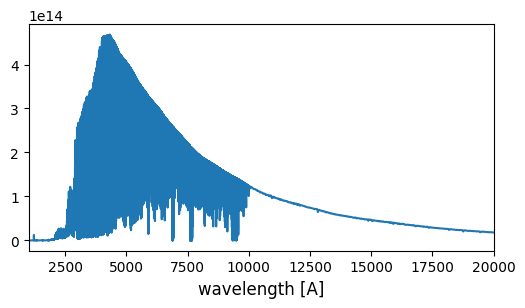

In [5]:
#  prepare solar radiation spectrum

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vt=5.E5)
solar_spec_H = Radiation.init_Radiation_()
solar_spec_H.solar[1, :] *= 0.5  # legacy intensity factor (was 3rd arg in old API)
wl0 = solar_spec_H.solar[0,:]*1E8  # wavelength of background spectrum [A]
Isun = solar_spec_H.solar[1,:]  # intensity of   "    [erg/cm^3/s/str]

fig, ax = plt.subplots(1,1, figsize=(6,3), dpi=100)
ax.plot(wl0, Isun)
ax.set_xlim(1000, 20000)
#ax.set_ylim(0,0.1E14)
#ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

In [28]:
HelpUtil.help_( atmos )

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atmosphere0D
|- Nh                      float                                v: 1000000000000.0
|- Ne                      float                                v: 100000000000.0
|- Te                      float                                v: 7000.0
|- Vd                      float                                v: 0.0
|- Vt                      float                                v: 500000.0
|- ndim                    int                                  v: 0
|- is_uniform              bool                                 v: True
|- Tr                      float                                v: 6000.0
|- use_Tr                  bool                                 v: False
|- doppler_shift_continuum  bool                   

## output intensity profile from a slab

In [9]:
from spectra.Function.SlabModel import CloudModel

Te = 1e4
Nh = 1e11
Ne = 1e10
Vt = 1e5            #   km * 1e5
depth = 1.E3 * 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity


In [14]:
HelpUtil.help_(SE_H)
HelpUtil.help_(lH)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
SE_Container
|- n_SE                    ndarray                              s: (9,)
|- n_LTE                   ndarray                              s: (9,)
|- nj_by_ni                ndarray                              s: (36,)
|- wave_mesh_shifted_1d    ndarray                              s: (1148,)
|- absorb_prof_1d          ndarray                              s: (1148,)
|- Line_mesh_idxs          ndarray                              s: (28, 2)
|- Jbar                    ndarray                              s: (28,)
------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
---------------------------------------

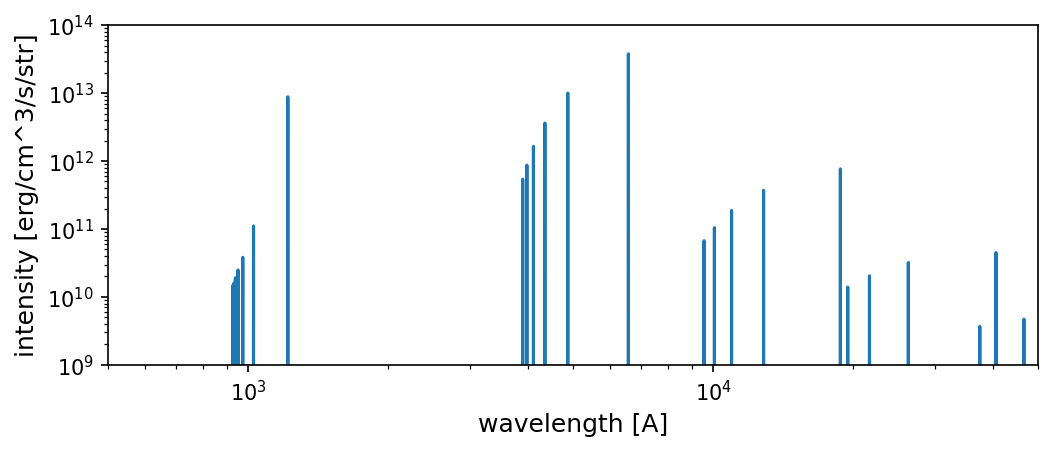

In [11]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(lH.wl_1D*1e8,lH.prof_1D)
ax.set_xlim(500, 50000)
ax.set_ylim(1e9,1E14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.show()

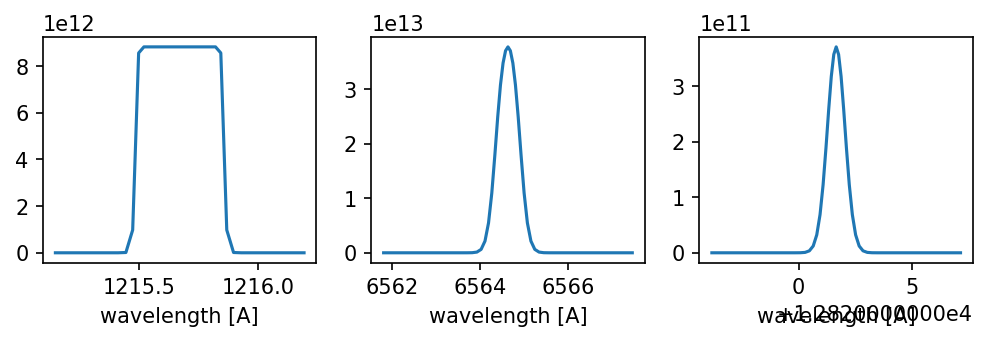

In [27]:
#-- extract one prof from l.wl_1D, l.prof_1D
def each_prof(l,SE_con,il):
    idx = SE_con.Line_mesh_idxs[il,:]
    wl = l.wl_1D[idx[0]:idx[1]]
    prof = l.prof_1D[idx[0]:idx[1]]
    return wl,prof

#----------------------------------------
fig, axs = plt.subplots(1,3, figsize=(8,2), dpi=150)

for k in [0]:
    for j in [0,1,2]:
        wl, prof = each_prof(lH,SE_H,j*7+k)
        axs[j].plot(wl*1e8,prof)
        axs[j].set_xlabel("wavelength [A]", fontsize=10)
        #axs[k,j].set_ylabel("intensity [erg/cm^3/s/str]", fontsize=10)
        
plt.show()

In [15]:
SE_H.Line_mesh_idxs
l.w0

array([1.21566939e-05, 1.02572139e-05, 9.72536275e-06, 9.49742817e-06,
       9.37803414e-06, 9.30747846e-06, 9.26225508e-06, 6.56462887e-05,
       4.86269663e-05, 4.34169950e-05, 4.10290933e-05, 3.97120433e-05,
       3.89016341e-05, 1.87562102e-04, 1.28216606e-04, 1.09411640e-04,
       1.00521462e-04, 9.54862921e-05, 4.05230017e-04, 2.62589326e-04,
       2.16611650e-04, 1.94509391e-04, 7.45993839e-04, 4.65371128e-04,
       3.74054716e-04, 1.23712010e-03, 7.50237057e-04, 1.90627577e-03])

In [22]:
wl*1e8

array([12816.14990694, 12816.89628205, 12817.52965061, 12818.06942171,
       12818.53167091, 12818.92971273, 12819.27457493, 12819.57539121,
       12819.83972654, 12820.07384659, 12820.28294091, 12820.4713077 ,
       12820.64250697, 12820.79948726, 12820.94469072, 12821.08014004,
       12821.20751051, 12821.32818969, 12821.44332683, 12821.55387377,
       12821.6606189 , 12821.76736403, 12821.87791097, 12821.9930481 ,
       12822.11372728, 12822.24109775, 12822.37654707, 12822.52175053,
       12822.67873083, 12822.84993009, 12823.03829689, 12823.2473912 ,
       12823.48151126, 12823.74584659, 12824.04666286, 12824.39152506,
       12824.78956689, 12825.25181608, 12825.79158718, 12826.42495574,
       12827.17133086])

In [85]:
np.linspace(0,10,10)

array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
        5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ])

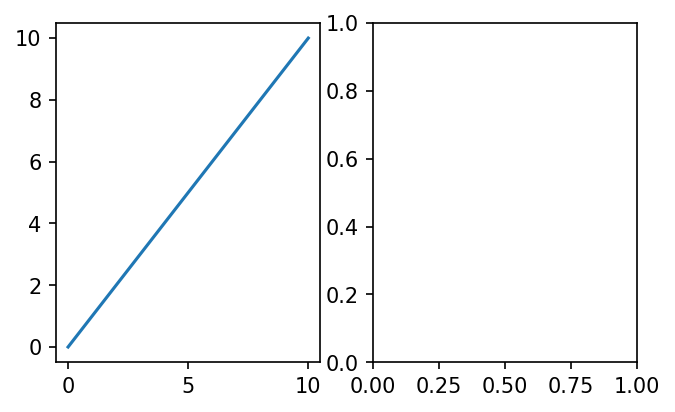

In [91]:
fig, ax = plt.subplots(1,2, figsize=(5,3), dpi=150)

ax[0].plot(np.linspace(0,10,10),np.linspace(0,10,10))

plt.show()